# 6 Decision_Trees_and_ensemble_learning

# 6.1 Credit Risk Scoring  信用风险评分

### 本课的内容，就是：银行可以利用一些个人的数据，通过模型，来做出你的信用风险评分，进而对是否放贷给你，得到评估结果。
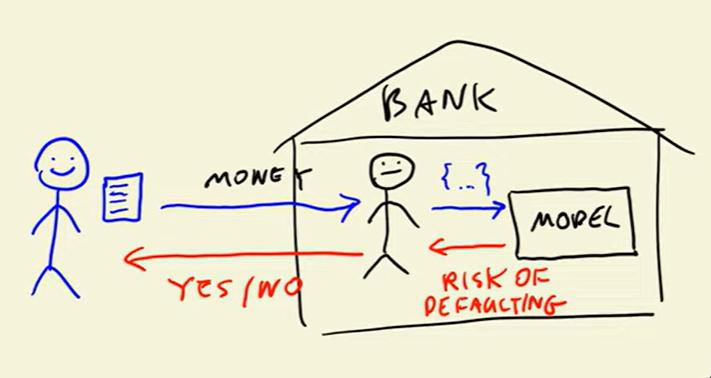

In [2]:
Dataset:https://github.com/gastonstat/CreditScoring  #手动登录该地址，下载CreditScoring.csv文件

SyntaxError: invalid syntax (1891506979.py, line 1)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import  pyplot as plt
%matplotlib  inline

# 6.2 Data cleaning and preparation

In [4]:
!head CreditScoring.csv

"Status","Seniority","Home","Time","Age","Marital","Records","Job","Expenses","Income","Assets","Debt","Amount","Price"
1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
1,0,1,36,26,1,1,1,46,107,0,0,310,910
1,1,2,60,36,2,1,1,75,214,3500,0,650,1645
1,29,2,60,44,2,1,1,75,125,10000,0,1600,1800
1,9,5,12,27,1,1,1,35,80,0,0,200,1093
1,0,2,60,32,2,1,3,90,107,15000,0,1200,1957


In [5]:
df = pd.read_csv('CreditScoring.csv')
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [6]:
df.dtypes

Status       int64
Seniority    int64
Home         int64
Time         int64
Age          int64
Marital      int64
Records      int64
Job          int64
Expenses     int64
Income       int64
Assets       int64
Debt         int64
Amount       int64
Price        int64
dtype: object

In [7]:
df.columns = df.columns.str.lower() 
df.columns

Index(['status', 'seniority', 'home', 'time', 'age', 'marital', 'records',
       'job', 'expenses', 'income', 'assets', 'debt', 'amount', 'price'],
      dtype='str')

### https://github.com/gastonstat/CreditScoring/blob/master/Part1_CredScoring_Processing.R
### 上面这个网址，可以看到如下内容
#### specify categorical variables as factors
dd$Status = as.factor(dd$Status)

dd$Home = as.factor(dd$Home)

dd$Marital = as.factor(dd$Marital)

dd$Records = as.factor(dd$Records)

dd$Job = as.factor(dd$Job)

#### change factor levels (i.e. categories)
levels(dd$Status) = c("good", "bad")

levels(dd$Home) = c("rent", "owner", "priv", "ignore", "parents", "other")

levels(dd$Marital) = c("single", "married", "widow", "separated", "divorced")

levels(dd$Records) = c("no_rec", "yes_rec")

levels(dd$Job) = c("fixed", "partime", "freelance", "others")


### 上面这个内容，告诉我们：Status，Home，Marital，Records，Job ，都是该数据集的‘分类特征字段’
### 处理分类特征字段，转换为str类型，并将数值对应的转换为字符串

In [8]:
df.home.unique()

array([1, 2, 5, 3, 6, 4, 0])

In [9]:
df.status.unique()

array([1, 2, 0])

In [10]:
# 以下是这些分类字段中，数值的含义，
# 将数值转换为对应得字符，并将字段类型修改为str
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [11]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [12]:
df.dtypes

status         str
seniority    int64
home           str
time         int64
age          int64
marital        str
records        str
job            str
expenses     int64
income       int64
assets       int64
debt         int64
amount       int64
price        int64
dtype: object

### ***处理缺失值/无效值***
该数据集中没有缺失值，但是有些字段的值，是用一些无效值，进行了填充，比如：99999999 这个数值填充字段值
我们需要将这些无效值，转换为NAN，否则这些值会影响模型精度。

In [13]:
df.isnull().sum()

status       0
seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

In [14]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [15]:
# 现有数据集中，缺失值的表示方式：99999999   

In [16]:
# 替换缺失值为NAN
for c in ['income','assets','debt']:
    df[c] = df[c].replace(to_replace=99999999,value=np.nan)

In [17]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [18]:
df.isnull().sum() # 这时候，无效值被替换为NAN后，会被统计出来，随后我们只需要把NAN填充为0，即可

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

In [19]:
df.status.value_counts()  # 发现unk 这个未知数的意思，是无用的。status列，我们是用来做为y值列来看待的，所以unk所在的这一行可以删除掉

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

In [20]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [21]:
# 过滤掉 status列中，内容为 unk 的行，这里有1行符合要求，所以过滤后df的行数，比初始行数少了一行。
df = df[df.status != 'unk'].reset_index(drop=True)
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [22]:
# 查看其他分类字段的unk情况，并做对应处理
for unk in ['home','marital','records','job']:
    df = df[df[unk] != 'unk'].reset_index(drop=True)

In [23]:
df 

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4441,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4442,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4443,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4444,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


### 分段数据

In [24]:
from  sklearn.model_selection import train_test_split

In [25]:
df_full_train,df_test = train_test_split(df,test_size=0.2,random_state=11)
df_train,df_val = train_test_split(df_full_train,test_size=0.25,random_state=11)

In [26]:
df_train 

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
4200,ok,7,rent,60,33,married,no,fixed,84,240.0,0.0,0.0,1000,1928
314,ok,0,owner,36,24,single,no,partime,45,97.0,8000.0,0.0,600,1542
3021,ok,12,owner,36,49,married,no,freelance,35,78.0,12000.0,2000.0,1000,1200
4012,default,14,owner,60,47,widow,yes,fixed,35,100.0,4000.0,2000.0,1475,1475
1702,ok,25,owner,48,55,married,no,fixed,60,139.0,5000.0,0.0,1000,1300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,ok,1,owner,60,44,married,no,freelance,90,905.0,20000.0,15000.0,1200,1381
979,default,4,rent,60,52,married,no,fixed,97,72.0,0.0,0.0,1200,1200
2906,ok,13,parents,36,27,single,no,fixed,35,105.0,0.0,0.0,500,800
3195,ok,0,rent,60,31,married,no,others,60,0.0,5000.0,0.0,1300,1572


In [27]:
df_train  = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [28]:
df_train.status

0            ok
1            ok
2            ok
3       default
4            ok
         ...   
2662         ok
2663    default
2664         ok
2665         ok
2666         ok
Name: status, Length: 2667, dtype: str

In [29]:
# 把数据集中的状态值单独拿出来，成为数据集的目标值
y_train = (df_train.status == 'default').astype('int').values 
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [30]:
y_train[:5] # 查看前5行，与df_train.status的前五行，是对应的。

array([0, 0, 0, 1, 0])

In [31]:
del df_train['status']
del df_val['status']
del df_test['status']

In [35]:
df_train.status  # 确认status列，已经被删除了

AttributeError: 'DataFrame' object has no attribute 'status'

# 6.3 Decision trees
·How a decision tree looks like   决策树的结构示意图  

·Training a decision tree         训练决策树  

·Overfitting                      过拟合问题  

·Controlling the size of a tree   控制树的大小

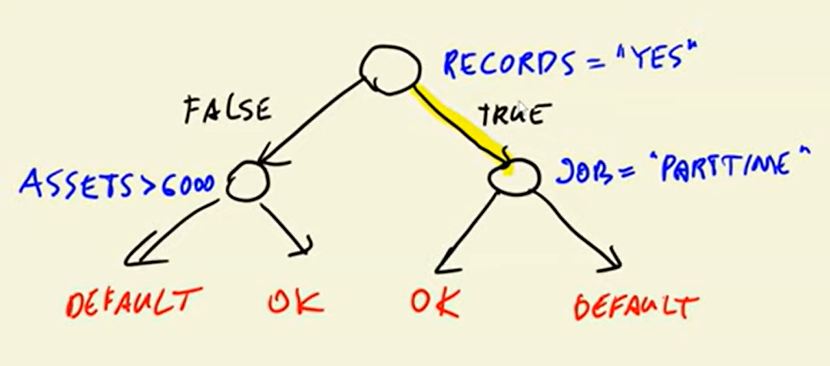

In [36]:
# 上图是 决策树  得1个示例，用代码实现如下：
def  assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime': 
            return'default'
        else:
            return'ok'
    else:
        if client['assets']> 6000:
            return'ok'
        else:
            return 'default'

In [37]:
# 把训练集得第一行记录，转为字典类型
xi = df_train.iloc[0].to_dict()
xi

{'seniority': 7,
 'home': 'rent',
 'time': 60,
 'age': 33,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 84,
 'income': 240.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1928}

In [38]:
assess_risk(xi)

'default'

In [38]:
from sklearn.tree import DecisionTreeClassifier        # 一个基于树结构的分类模型，用于解决二分类或多分类问题。
from sklearn.feature_extraction import DictVectorizer  # 将字典（dict）列表转换成机器学习模型能吃的数值矩阵

In [40]:
train_dicts = df_train.fillna(0).to_dict(orient='records')  #这里进行了NAN值得填充，用0

In [41]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [42]:
X_train

array([[3.30e+01, 1.00e+03, 0.00e+00, ..., 0.00e+00, 7.00e+00, 6.00e+01],
       [2.40e+01, 6.00e+02, 8.00e+03, ..., 0.00e+00, 0.00e+00, 3.60e+01],
       [4.90e+01, 1.00e+03, 1.20e+04, ..., 0.00e+00, 1.20e+01, 3.60e+01],
       ...,
       [2.70e+01, 5.00e+02, 0.00e+00, ..., 0.00e+00, 1.30e+01, 3.60e+01],
       [3.10e+01, 1.30e+03, 5.00e+03, ..., 0.00e+00, 0.00e+00, 6.00e+01],
       [4.30e+01, 1.37e+03, 6.50e+03, ..., 0.00e+00, 1.00e+01, 3.60e+01]],
      shape=(2667, 26))

In [43]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'income', 'job=fixed', 'job=freelance', 'job=others',
       'job=partime', 'marital=divorced', 'marital=married',
       'marital=separated', 'marital=single', 'marital=widow', 'price',
       'records=no', 'records=yes', 'seniority', 'time'], dtype=object)

In [44]:
# 训练决策树模型
dt_model = DecisionTreeClassifier() # 实例化模型
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [45]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [46]:
y_pred = dt_model.predict_proba(X_val)[:,1]  # 第0列 = 预测为 "非违约"（ok） 的概率, 第1列 = 预测为 "违约"（default） 的概率
y_pred

array([0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.,
       0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0.

In [37]:
from sklearn.metrics import  roc_auc_score

In [48]:
roc_auc_score(y_val,y_pred)

0.6699311424100157

In [49]:
y_pred = dt_model.predict_proba(X_train)[:,1]  # 看训练数据集得结果
roc_auc_score(y_train,y_pred)

1.0

###  以上得情况：验证数据集得auc是0.67，训练数据集得auc是1，这种情况就叫做‘过度拟合’。
### 健康模型得auc：
- 训练集 AUC ≈ 0.85

- 验证集 AUC ≈ 0.82

- 差距 ≈ 0.03（较小）
#### 过度拟合：overfitting，模型只记住训练集得数据，***泛化能力不足***，在新得数据上，判断力变得很差。
#### 导致过拟合的原因：
- ***下面来逐步说明：***

In [50]:
# 我们看训练数据集的第一行和它的标签向量的结果
xi

{'seniority': 7,
 'home': 'rent',
 'time': 60,
 'age': 33,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 84,
 'income': 240.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1928}

In [51]:
y_train[0]

np.int64(0)

In [52]:
y_pred[0]

np.float64(0.0)

####  可以看到：
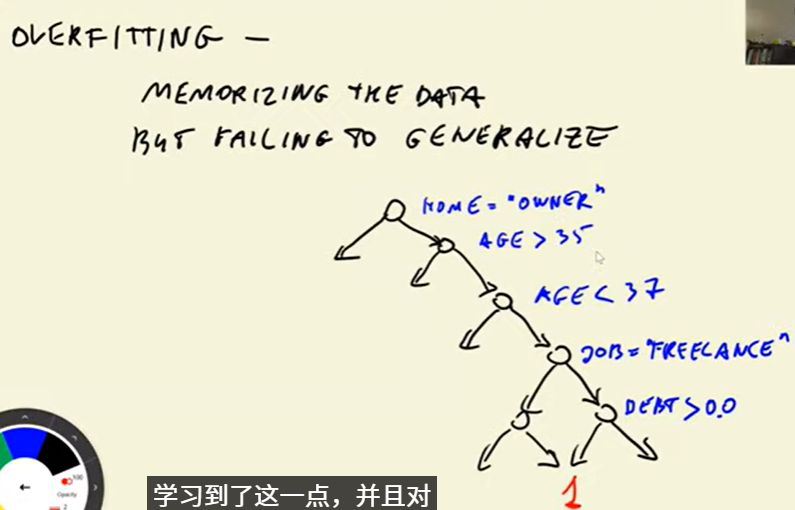
- 图中画的内容，就是对训练数据集第一行数据，利用决策树机制，进行学习判断的逻辑推演。
- 但是这个判断逻辑，可能到了val验证数据集中，就会出现大范围的不匹配，导致auc值较低。
- 从图中可以看到，决策树的深度，大概是5-6层，说明：只要决策树的深度足够深，就可以学习到任何可能的组合，任何可能的客户数据。
决策树本质上是一个贪心算法，它通过不断划分特征空间，最终可以将训练数据切分成极其精细的“小格子”。

理论上，如果不做任何限制（max_depth=None，min_samples_split=2，min_samples_leaf=1），决策树可以不断分裂，直到每个叶子节点只包含一个样本（或全部是同一类别）。

- **根节点**：	树的最顶层起始节点，可以继续分裂，没有父节点，包含全部样本。
- **内部节点**：某个节点分裂后产生的下一层节点，可以继续分裂，有父节点，也有子节点
- **叶子节点**：是决策树中不再继续分裂的终端节点，代表最终的决策结果；
- **样本**：就是数据集中得每一行数据。


这意味着，训练集的每一个样本，都可以被树“记住”。每个样本在树中都有唯一的一条路径，最终到达一个只属于它自己的叶子节点。
所以从数学上讲，深度足够大的决策树，确实可以“学习”到训练集中任何一种样本组合，并在训练集上达到100%的准确率（或AUC=1.0）。
这就像一本“字典”：你把训练集里每一个客户的所有特征都写进去，然后标注“违约/不违约”。以后遇到一个完全一样的客户，你就翻字典查答案。在训练集上，这本字典是完美无缺的。

机器学习的目标不是“记住训练集”，而是“泛化”（Generalization），即对新数据也能做出正确预测。

深度过深的决策树，记住的不是“规律”，而是训练集中的“噪声”和“特例”。

当这棵树遇到一个新的、没见过的客户时，它会用那些基于“特例”学到的规则去判断，结果往往很差。

这本质上就是“过拟合”（Overfitting）——训练集上“完美”，验证集上“崩溃”。

前面遇到的 训练集AUC=1.0，验证集AUC≈0.65，就是最典型的例子。

- “决策树的深度足够深，可以‘记住’任何训练数据。”

- “但机器学习想要的是‘理解’，而不是‘背诵’。”

- 为了避免“过拟合”，你必须限制决策树的复杂度：

- ***限制树的深度***，  强制学“大规律”    max_depth=6

- ***限制叶子节点最小样本数***，避免为“特例”建规则    min_samples_leaf=20   #分裂后：子节点至少需要多少样本才允许分裂

- ***限制分裂所需的最小样本数***，避免在样本太少的节点上继续分裂   min_samples_split=20  # 分裂前：节点至少需要多少样本才考虑分裂

In [59]:
# 我们来验证，上述描述中，对决策树模型的参数的控制
dt_model = DecisionTreeClassifier(max_depth = 5) # 实例化模型
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [60]:
y_pred = dt_model.predict_proba(X_val)[:,1]
auc_val = roc_auc_score(y_val,y_pred)
print(f'auc_val:{auc_val}')

auc_val:0.7978059467918623


In [61]:
y_pred = dt_model.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train,y_pred)
print(f'auc_train:{auc_train}')

auc_train:0.8264627033168002


#### 显然，给决策树模型，增加max_depth = 5的参数配置后，验证数据集的AUC变得好多了，成功地把模型从“死记硬背”的学渣，变成了“掌握方法”的优等生。
##### 之前（默认深度）：训练集 AUC = 1.0，验证集 AUC ≈ 0.66（差距 0.34）
##### 现在（max_depth=5）：训练集 AUC = 0.826，验证集 AUC = 0.797（差距 0.029）
##### 训练集 AUC 从 1.0 降到 0.826，验证集 AUC 从 0.65 升到 0.797。
##### 这说明：模型不再“背答案”了，而是真正开始“学规律”。
##### 下图是，三层决策树，和只有1层的决策树，一层的决策树，叫做***stump***
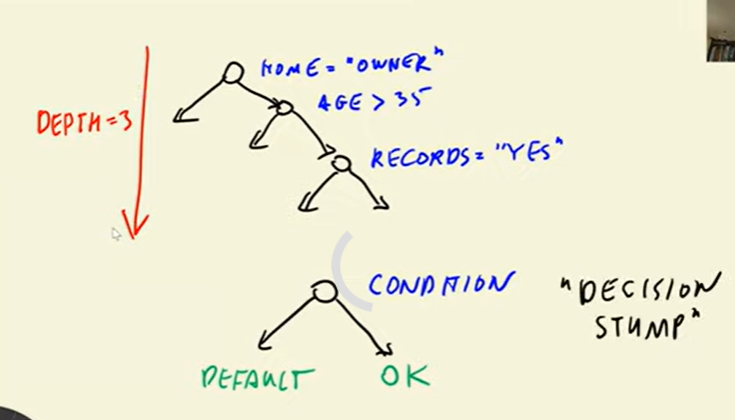

In [62]:
# 可视化的决策树
from sklearn.tree  import export_text

In [63]:
# 打印决策树,可以看到，这是个5层的判断结构：从根节点（最顶部）到最深的叶子节点，最多只会经历 5 次判断（即 5 层）
print(export_text(dt_model,feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 945.00
|   |   |   |--- price <= 887.00
|   |   |   |   |--- time <= 42.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- time >  42.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- price >  887.00
|   |   |   |   |--- income <= 311.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- income >  311.00
|   |   |   |   |   |--- class: 1
|   |   |--- amount >  945.00
|   |   |   |--- assets <= 8250.00
|   |   |   |   |--- assets <= 500.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- assets >  500.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  8250.00
|   |   |   |   |--- income <= 97.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- income >  97.50
|   |   |   |   |   |--- class: 0
|   |--- seniority >  6.50
|   |   |--- income <= 109.50
|   |   |   |--- assets <= 8750.00
|   |   |   |   |--- amount <= 612.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- 

# 6.4 Decision tree learning algorithm
·Finding the best split for one column   对某一列寻找最佳划分  

·Finding the best split for the entire dataset   对整个数据集寻找最佳划分  

·Stopping criteria                               停止准则  

·Decision tree learning algorithm                决策树学习算法

### 看alexey老师画的图：条件节点condition node，leaves decision node 叶子决策节点
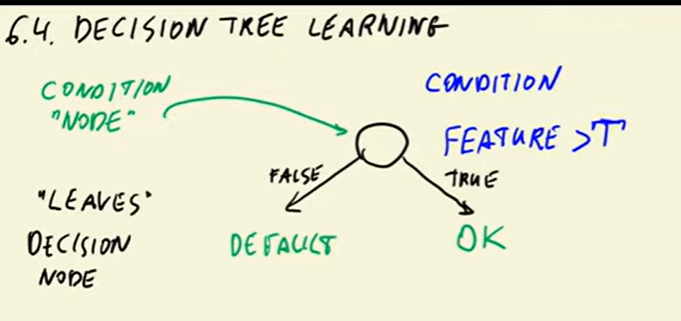

In [52]:
# 代码实现
data =[
[8000,'default'],
[2000,'default'],
[0,'default'],
[5000,'ok'],
[5000,'ok'],
[4000,'ok'],
[9000,'ok'],    
[3000,'default'],
]

In [53]:
df_example = pd.DataFrame(data,columns=['assets','status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


#### 
这段代码是在手动模拟决策树寻找最佳分裂点的过程。
这段代码想要回答一个问题：
“如果只用 assets（资产）这一个特征来判断客户是否违约，设哪个门槛值（T）最好？”

In [54]:
# 对数据集进行排序，根据资产列大小，升序排列
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


#### 对资产类assets，潜在阈值是：0，2000，3000，4000，5000，8000，进行split，
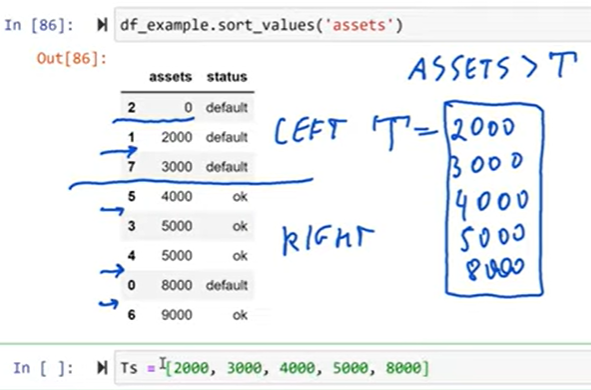

In [55]:
Ts = [0,2000,3000,4000,5000,8000] 

In [56]:
from IPython.display  import display

In [57]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))

    print('==================')

0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
2000


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
3000


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


##  把上面的结果绘制到一张表中
| T 值 | Decision Left | Impurity Left | Decision Right | Impurity Right | Avg Impurity |
| :---: | :--- | :---: | :--- | :---: | :---: |
| 0 | DEFAULT | 0% | OK | 43% | 21.5% |
| 2000 | DEFAULT | 0% | OK | 33% | 16.5% |
| 3000 | DEFAULT | 0% | OK | 20% | 10.0% |
| 4000 | DEFAULT | 25% | OK | 25% | 25.0% |
| 5000 | DEFAULT | 50% | OK | 50% | 50.0% |
| 8000 | DEFAULT | 43% | OK | 0% | 21.5% |


## 决策树会选哪个 T 值？
- 决策树会计算每个 T 值的“加权不纯度”（Gini 不纯度），然后选择不纯度最小的那个 T。
- **✅ Best T = 3000, Avg Impurity: 10%**
- 最佳门槛值：T = 3000
为什么？

Avg Impurity = 10%，是所有候选值中最低的。

左子树 100% 是 DEFAULT（纯的），右子树只有 20% 是 DEFAULT（杂质很低）。

综合来看，3000 这个门槛的整体分类效果最好。

### 以上部分是对1列特征，作为模拟决策树寻找最佳分裂点的过程
### 接下来我们使用两列特征值


In [58]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000,  500, 'ok'],
    [3000, 2000, 'default'],
]

df_example2 = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example2

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [59]:
df_example2.sort_values('debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [60]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [61]:
for feature, Ts in thresholds.items():
    print('#####################')
    print(feature)
    for T in Ts:
        print(T)
        df_left = df_example2[df_example2[feature] <= T]
        df_right = df_example2[df_example2[feature] > T]

        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))

        print()
    print('#####################')

#####################
assets
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64

#####################
#####################
debt
500


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64

1000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

#####################


### ### 📊 assets 和 debt 特征的分裂效果（Alexey 格式）

#### 按 assets 分裂

| T 值 | Decision Left | Impurity Left | Decision Right | Impurity Right | Avg Impurity |
| :---: | :--- | :---: | :--- | :---: | :---: |
| 0 | DEFAULT | 0%（0/1） | OK | 43%（4/7） | 21.5% |
| 2000 | DEFAULT | 0%（0/2） | OK | 33%（2/6） | 16.5% |
| 3000 | DEFAULT | 0%（0/3） | OK | 20%（1/5） | 10.0% |
| 4000 | DEFAULT | 25%（1/4） | OK | 25%（1/4） | 25.0% |
| 5000 | DEFAULT | 50%（3/6） | OK | 50%（1/2） | 50.0% |
| 8000 | DEFAULT | 43%（3/7） | OK | 0%（0/1） | 21.5% |


**✅ Best T = 3000, Avg Impurity: 10%**

#### 按 debt 分裂

| T 值 | Decision Left | Impurity Left | Decision Right | Impurity Right | Avg Impurity |
| :---: | :--- | :---: | :--- | :---: | :---: |
| 500 | OK | 0%（0/1） | DEFAULT | 43%（4/7） | 21.5% |
| 1000 | OK | 33%（2/6） | DEFAULT | 0%（0/2） | 16.5% |
| 2000 | OK | 43%（3/7） | DEFAULT | 0%（0/1） | 21.5% |

**✅ Best T = 1000, Avg Impurity: 16.5%**

### 决策树会选哪个 T 值？
决策树会计算每个 T 值的“加权不纯度”（Gini 不纯度），然后选择不纯度最小的那个 T。

✅ Best T = 3000, Avg Impurity: 10%

最佳门槛值： assets T = 3000   为什么？

Avg Impurity = 10%，是所有候选值中最低的。

左子树 100% 是 DEFAULT（纯的），右子树只有 20% 是 DEFAULT（杂质很低）。

综合来看，3000 这个门槛的整体分类效果最好。

✅ Best T = 1000, Avg Impurity: 16.5%
同理这个会选择 1000

# 6.5 Decision trees parameter tuning   决策树参数调优
· selecting max_depth                  选择 max_depth：决定了决策树从根节点到叶子节点的最长路径长度（即最多能进行多少次分裂）。

· selecting min_samples_leaf           选择 min_samples_leaf:如果一个节点在分裂后，它的某个子节点中的样本数量少于 min_samples_leaf，那么这个节点就不会被允许分裂。

In [64]:
for d in [1,2,3,4,5,6,10,15,20,None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train,y_train)

    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val,y_pred)

    print(f'depth is {d}  ->  auc is {auc:.3f}')

depth is 1  ->  auc is 0.631
depth is 2  ->  auc is 0.742
depth is 3  ->  auc is 0.789
depth is 4  ->  auc is 0.799
depth is 5  ->  auc is 0.799
depth is 6  ->  auc is 0.791
depth is 10  ->  auc is 0.665
depth is 15  ->  auc is 0.598
depth is 20  ->  auc is 0.674
depth is None  ->  auc is 0.660


#### 以上结果，***如果max_dept是唯一的参数***，我们可以选择 ‘4’ ，因为，4，5，6都非常接近了，但是原则上优先选择层数更少的
#### 但是，现在不仅仅是1个参数，还有另外1个参数

In [65]:
scores = []

for depth in [4,5,6,7,10,15,20,None]:
    for s in [1,2, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=d,min_samples_leaf=s)
        dt.fit(X_train,y_train)

        y_pred =  dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((depth,s,auc))
scores

[(4, 1, 0.666018779342723),
 (4, 2, 0.6863474178403756),
 (4, 5, 0.7376964006259781),
 (4, 10, 0.7798779342723005),
 (4, 15, 0.8031768388106416),
 (4, 20, 0.8057120500782473),
 (4, 500, 0.7365758998435055),
 (4, 100, 0.8233677621283255),
 (4, 200, 0.807433489827856),
 (5, 1, 0.6641064162754304),
 (5, 2, 0.6858779342723005),
 (5, 5, 0.7382159624413145),
 (5, 10, 0.778431924882629),
 (5, 15, 0.80720813771518),
 (5, 20, 0.8058215962441315),
 (5, 500, 0.7365758998435055),
 (5, 100, 0.8233677621283255),
 (5, 200, 0.807433489827856),
 (6, 1, 0.6732363067292644),
 (6, 2, 0.6778184663536776),
 (6, 5, 0.7339968701095462),
 (6, 10, 0.7800907668231611),
 (6, 15, 0.8029953051643193),
 (6, 20, 0.8054460093896714),
 (6, 500, 0.7365758998435055),
 (6, 100, 0.8233677621283255),
 (6, 200, 0.807433489827856),
 (7, 1, 0.6525414710485133),
 (7, 2, 0.6761846635367762),
 (7, 5, 0.7393458528951486),
 (7, 10, 0.7804287949921753),
 (7, 15, 0.8055054773082941),
 (7, 20, 0.8058403755868545),
 (7, 500, 0.73657589

In [66]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.sort_values(by='auc',ascending=False)

,max_depth,min_samples_leaf,auc
7,4.0,100,0.823368
52,15.0,100,0.823368
70,NaN,100,0.823368
61,20.0,100,0.823368
43,10.0,100,0.823368
...,...,...,...
9,5.0,1,0.664106
27,7.0,1,0.652541
45,15.0,1,0.649236
54,20.0,1,0.648541


In [67]:
# 它把 min_samples_leaf 变成行索引，把 max_depth 变成列索引，把 auc 作为表格里的值。
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)  

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.671  0.666  0.664  0.673  0.653  0.647  0.649  0.649
2                 0.675  0.686  0.686  0.678  0.676  0.691  0.685  0.692
5                 0.730  0.738  0.738  0.734  0.739  0.739  0.740  0.724
10                0.784  0.780  0.778  0.780  0.780  0.780  0.778  0.781
15                0.802  0.803  0.807  0.803  0.806  0.803  0.805  0.806
20                0.805  0.806  0.806  0.805  0.806  0.806  0.806  0.806
100               0.823  0.823  0.823  0.823  0.823  0.823  0.823  0.823
200               0.807  0.807  0.807  0.807  0.807  0.807  0.807  0.807
500               0.737  0.737  0.737  0.737  0.737  0.737  0.737  0.737

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

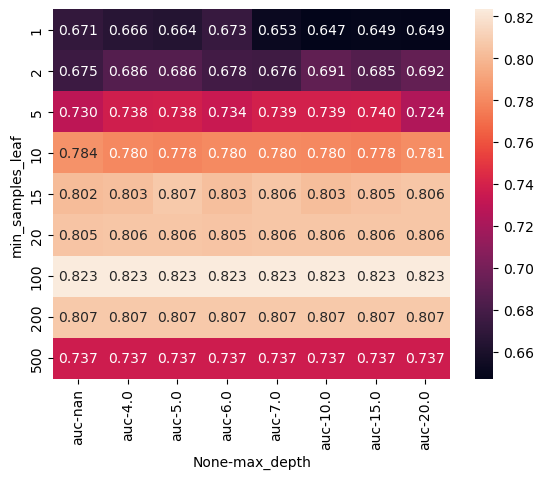

In [68]:
sns.heatmap(df_scores_pivot,annot=True,fmt=".3f")

### 调参思路：先寻找适合的深度，在选择适合的最小叶子数

In [69]:
# 用新的参数训练模型
dt_model2 =  DecisionTreeClassifier(max_depth=6, min_samples_leaf=100) 
dt_model2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

# 6.6 Ensembles and random forest           集合模型与随机森林
·Board of experts                           专家委员会 

·Ensembling models                           集成模型  

·Random forest - ensembling decision trees    随机森林——集成决策树  

·Tuning random forest                        随机森林调参

## Radom  Forest
- 先看下alexey老师画的图：

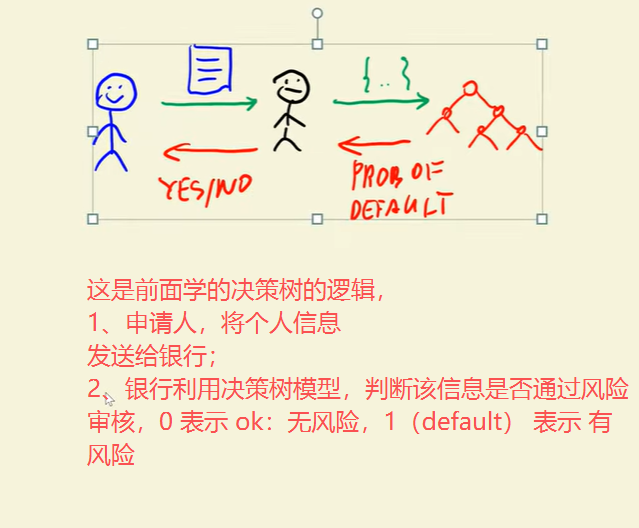

- 下面这幅图：1个常规的专家系统，可以利用多个模型（可以是任何模型），对同一份申请数据的判断，求取其平均值，作为最终判断的依据。
- 这就是集成学习（Ensemble）中最简单的“平均法”。

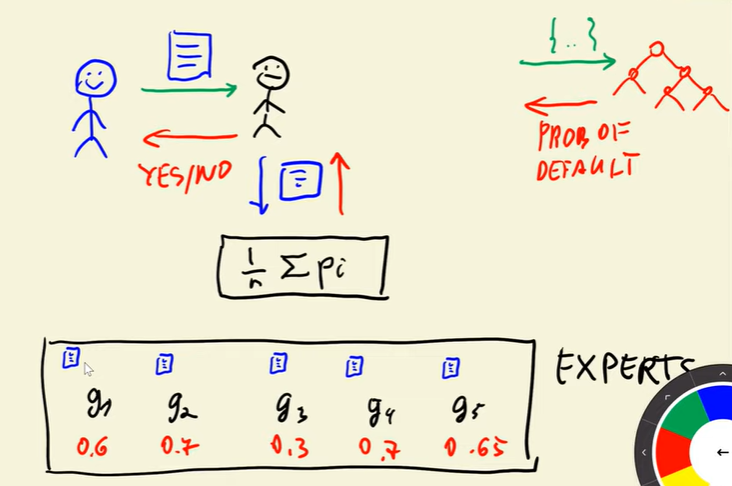
- 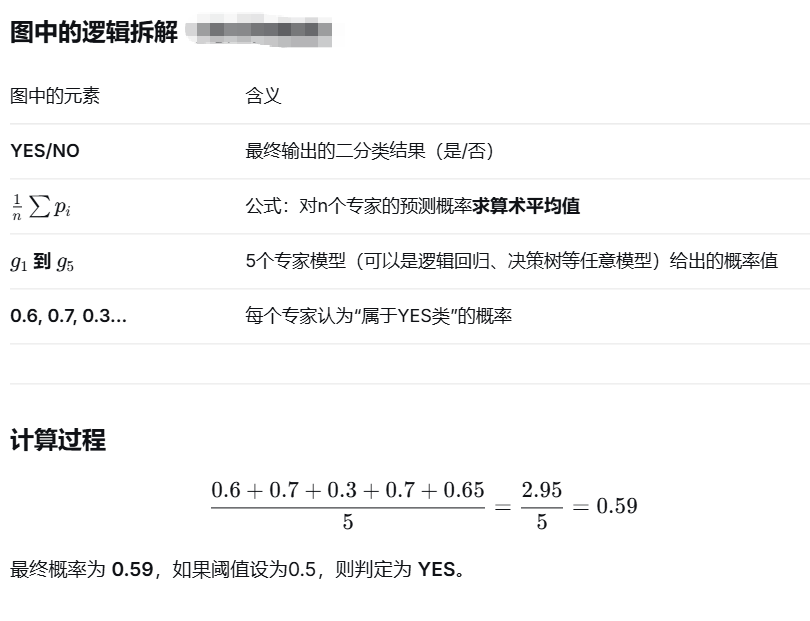

- 下面这幅图：把上图中的模型全部换成决策树模型，那就不叫作***experts***系统了，而叫做：***Random  Forest***

为什么这么定义呢？如果5个决策树模型都是一样的参数，那么针对同一份申请数据，得到的结果都是一样的，5个相同结果的平均值，也就都是一样的。
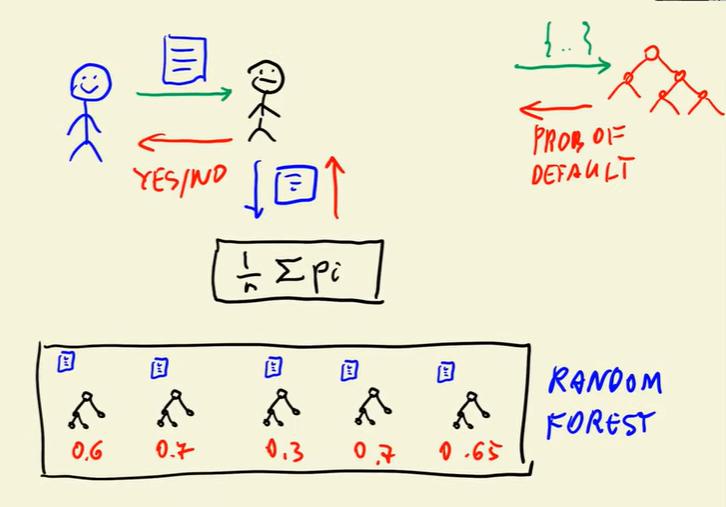

- Random  Forest 的逻辑思路：

如图，3个特征的数据集，我们可以把它搞成：两两组合的3个决策树模型，对同样的原始数据集做训练和预测，再求取3个模型结果的平均值
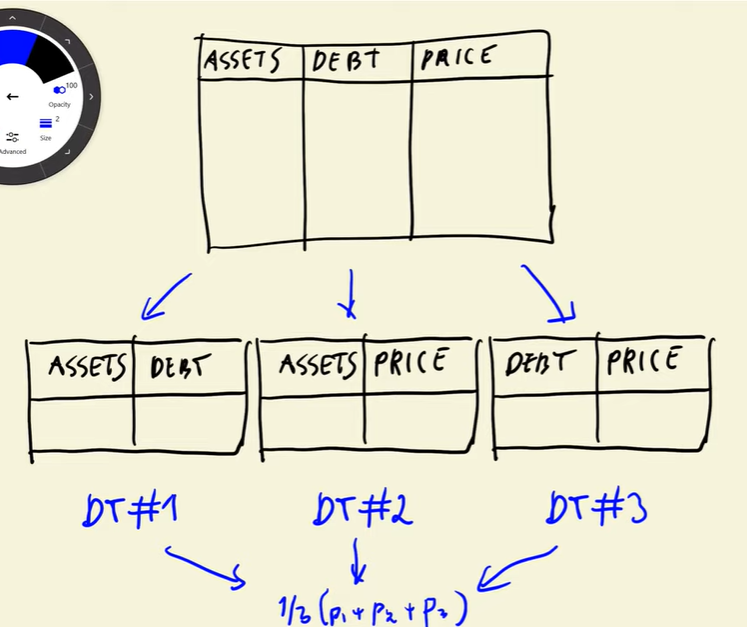

- 回到正题：Random  Forest 中的每个决策树模型的特征，是随机选择的

each model gets a random subset of feature：每个模型都会获得一组随机特征，和随机的数据（数据随机（Bootstrap抽样））
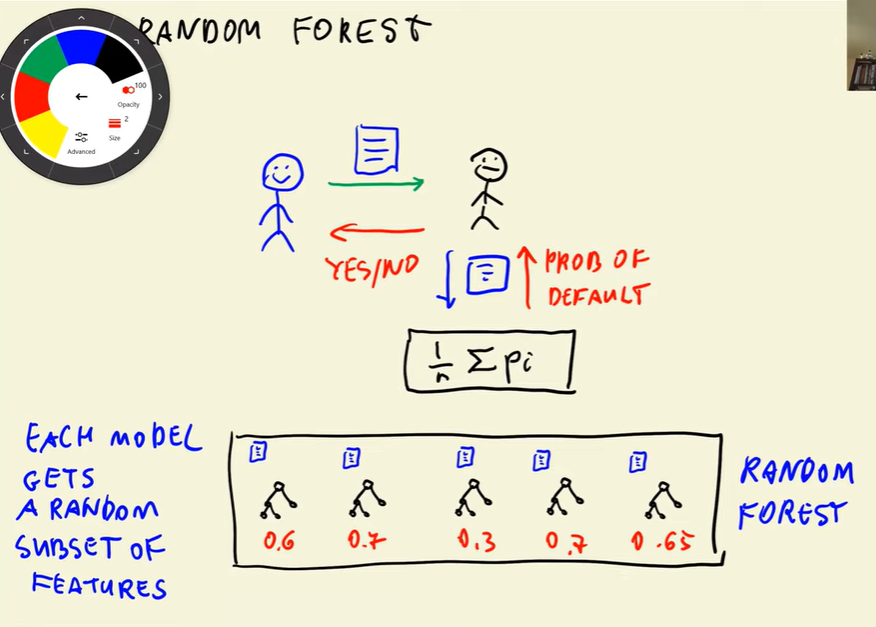





In [70]:
from  sklearn.ensemble import RandomForestClassifier

In [71]:
# n_estimators 决定随机森林里有多少棵决策树。
# random_state 是“随机数生成器”的种子，用来保证你每次运行代码时，随机过程产生的结果是一致的。
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    scores.append((n, auc))

In [72]:
scores

[(10, 0.8152676056338027),
 (20, 0.8365258215962442),
 (30, 0.8433082942097027),
 (40, 0.8490015649452269),
 (50, 0.8492237871674491),
 (60, 0.8495430359937401),
 (70, 0.8522691705790297),
 (80, 0.8524569640062598),
 (90, 0.8523630672926448),
 (100, 0.8534021909233177),
 (110, 0.8539154929577465),
 (120, 0.85381220657277),
 (130, 0.8543474178403756),
 (140, 0.8546353677621283),
 (150, 0.854697965571205),
 (160, 0.8542691705790296),
 (170, 0.8548544600938968),
 (180, 0.8546948356807512),
 (190, 0.8548888888888889),
 (200, 0.855399061032864)]

In [73]:
columns = ['n_estimators','auc']
df_scores2 = pd.DataFrame(scores,columns=columns)
df_scores2.sort_values(by='auc',ascending=False)

,n_estimators,auc
19,200,0.855399
18,190,0.854889
16,170,0.854854
14,150,0.854698
17,180,0.854695
13,140,0.854635
12,130,0.854347
15,160,0.854269
10,110,0.853915
11,120,0.853812


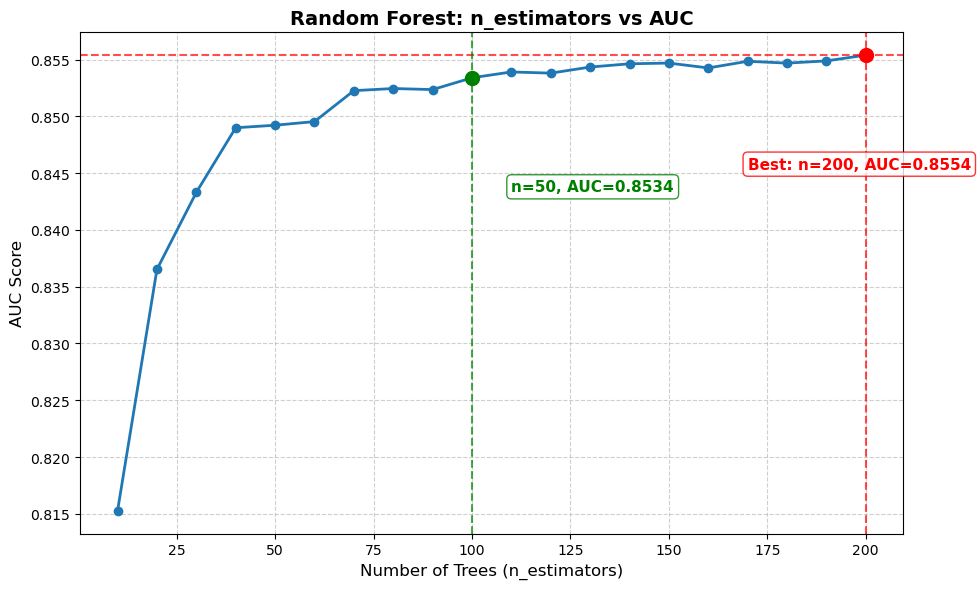

In [76]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# 1. 绘制折线图
plt.plot(df_scores2.n_estimators, df_scores2.auc, marker='o', linestyle='-', linewidth=2, markersize=6)

# 2. 添加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 3. 添加标题和坐标轴标签
plt.title('Random Forest: n_estimators vs AUC', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)

# ===== 4. 标记最高点（红色） =====
max_auc = df_scores2.auc.max()
max_idx = df_scores2.auc.idxmax()
max_n = df_scores2.loc[max_idx, 'n_estimators']

plt.axhline(y=max_auc, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axvline(x=max_n, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.scatter(max_n, max_auc, color='red', s=100, zorder=5)
plt.annotate(f'Best: n={max_n}, AUC={max_auc:.4f}',
             xy=(max_n, max_auc),
             xytext=(max_n * 0.85, max_auc - 0.01),
             fontsize=11,
             color='red',
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# ===== 5. 标记 n=50 的点（绿色） =====
# 找到 n=100 对应的数据行
row_100 = df_scores2[df_scores2.n_estimators == 100]
if not row_100.empty:
    auc_100 = row_100.auc.values[0]
    
    # 绿色虚线标记
    plt.axvline(x=100, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    plt.scatter(100, auc_100, color='green', s=100, zorder=5)
    plt.annotate(f'n=50, AUC={auc_100:.4f}',
                 xy=(100, auc_100),
                 xytext=(100 * 1.1, auc_100 - 0.01),  # 文字放在右上方
                 fontsize=11,
                 color='green',
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='green', alpha=0.8))
else:
    print("警告：数据中没有 n=100 对应的行，请检查 df_scores2 的数据范围。")
    # 如果没有 n=100，给个提示并在图中以绿色虚线显示 x=50
    plt.axvline(x=100, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    plt.text(50, plt.ylim()[0] + 0.02, 'n=100', color='green', fontsize=10, ha='center')

# 6. 显示图形
plt.tight_layout()
plt.show()

#### 总结1小下：
- 100个生成树模型的AUC是0.8534， 200个生成树模型的AUC是0.8554，相差无几，基本上可以认为：决策树模型，在100左右已经达到了理论最优点，因为100-200的区间，AUC变化并不大。
- 所以：***生成树的数量，我们选择100***：n_estimators = 100。后面的最终计算，选择了200.这个问题先留着不做深究

#### 接下来，我们把决策树的深度参数，加入进来

In [77]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, n, auc))

In [78]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

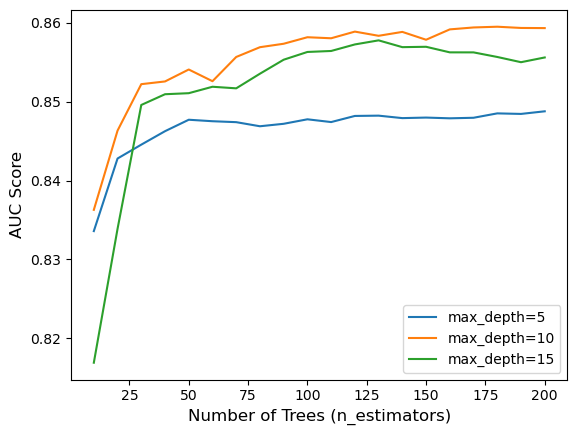

In [79]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend()

### 决策树深度为10，的情况，AUC表现是最好的。125颗树，基本上波动不大了。
- 所以，***我们选择的最大深度***：max_depth = 10

### - 接下来继续看 最小样本叶子数量    min_samples_leaf

In [80]:
scores = []
max_depth = 10
for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

In [81]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

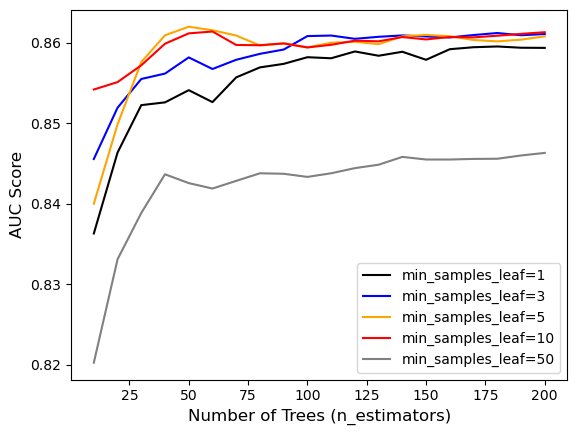

In [82]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]
# zip函数，会把两个列表的值，按照索引顺序，配对。它是一个“懒加载”的迭代器，里面装着多个元组。zip 像是一个“元组制造机”
#  [(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]
for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend()

### 结论：10，3，5的min_samples_leaf，AUC表现都比较优秀，但是橙色的更早的表现出了更好的AUC
- 所以我们选择  min_samples_leaf = 5

In [83]:

min_samples_leaf = 5
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [84]:
y_pred = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
auc

0.8607699530516432

# scikit-learn的官方网址：
scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
可以查看使用手册和参数详解。

# 6.7 Gradient boosting and XGBoost          梯度提升与XGBoost
· Gradient boosting vs random forest         梯度提升 vs 随机森林 

· Installing XGBoost                         安装XGBoost

· Training the first model                   训练第一个模型

· Performance monitoring                     性能监控 

· Parsing xgboost's monitoring output        解析XGBoost的监控输出


 ### 先看alexey给出的一个图
 ###  关于随机森林
 补充：随机性的两个核心恰好是随机森林能成功的根本原因：

- 数据随机（Bootstrap）：DT 1 到 DT 5 每棵树看到的训练数据不是同一份，而是从原始DATA中有放回抽取的不同子集。

- 特征随机：每棵树在分裂节点时，只能看到部分特征，而不是全部。

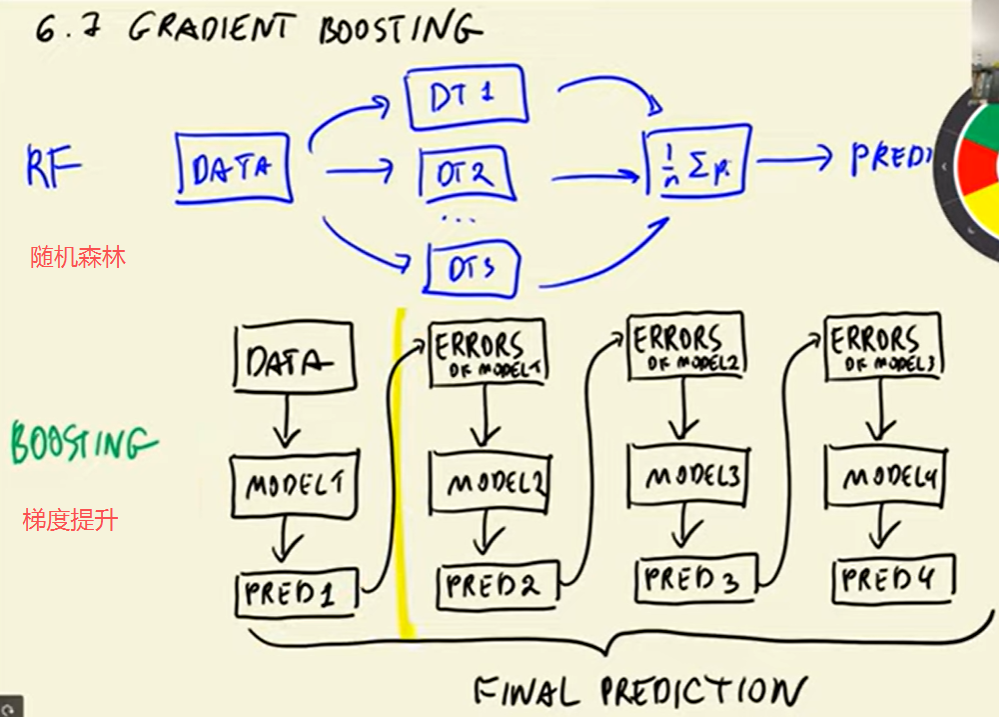

1. 随机森林是将DATA（数据） → 分别喂给 DT 1, DT 2, ..., DT 5（多棵决策树）。
2. 每棵树独立训练，互不干扰。
3. 最后把5棵树的结果汇总，输出 PRED（预测）：
4. 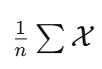

X 代表每棵树输出的结果（可以是类别标签，也可以是概率值）。

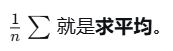

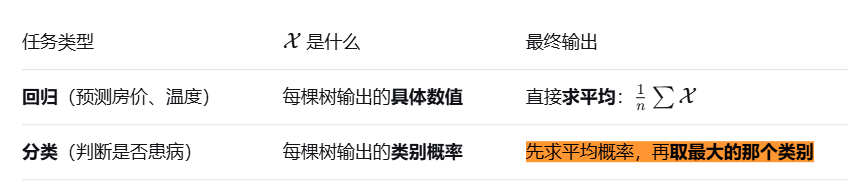  

- RandomForestClassifier → 专门用于分类任务

- RandomForestRegressor → 专门用于回归任务

###  关于梯度提升
- 随机森林是“三个臭皮匠，顶个诸葛亮”（平行投票）；
- 梯度提升是“一个老师傅带徒弟，徒弟专学师傅的失误”（串行纠错）。
图中的 ERRORS OF MODEL1 → MODEL2 → PRED2 这条链路，就是梯度提升最核心的“残差拟合”思想。这也是为什么梯度提升（尤其是 XGBoost/LightGBM）在很多结构化数据竞赛里表现优于随机森林——因为它会定向进化，而不是简单平均。



## 如果把梯度提升的模型，换为：决策树，那么这个东西就叫做：梯度提升树，引出新的模型：XGBoost
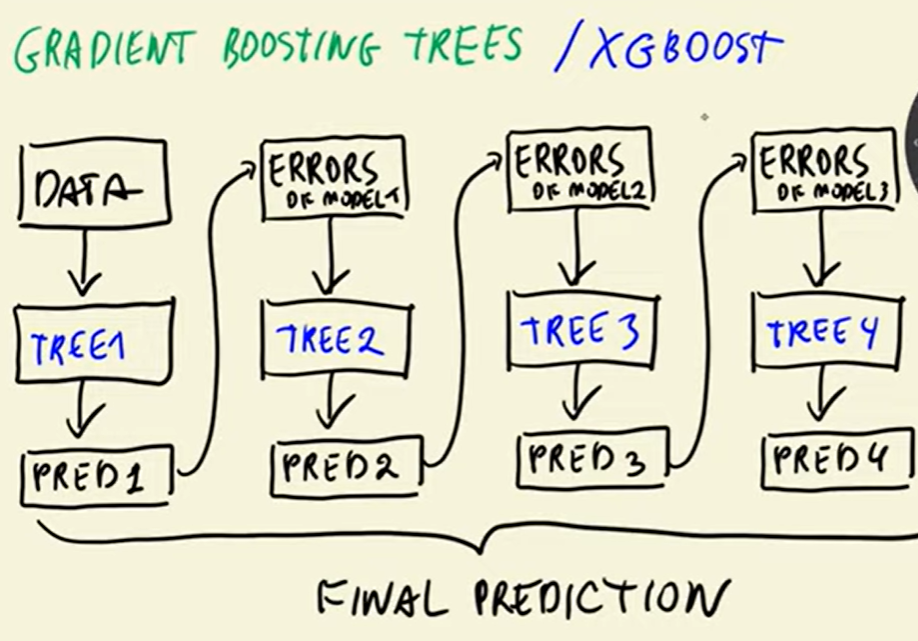


In [ ]:
# 在quant虚拟机中，安装xgboost
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# pip install xgboost

In [36]:
import  xgboost  as  xgb

In [86]:
 dv.get_feature_names_out().tolist()

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [87]:
# 将数据转换为需要的类型
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train,label=y_train,feature_names=features)
dval = xgb.DMatrix(X_val,label=y_val,feature_names=features)

In [88]:
xgb_params = {
    'eta':0.3,   # 学习率：值越小，模型越保守，需要更多的树（num_boost_round）来拟合，但通常更稳健。
    'max_depth':6,   # 树的最大深度
    'min_child_weight':1,  # 叶子节点所需的最小样本权重和：用于控制过拟合。值越大，算法在分裂时越保守，能有效防止模型学习到局部特殊样本。
    'nthread': 8,  # 指定 XGBoost 训练时使用的CPU 线程数,通常设为机器的物理核心数或逻辑核心数（如 8 核 16 线程的 CPU，可设为 8 或 16）。
# 如果设为 -1，XGBoost 会自动使用所有可用的核心。
    
    'objective':'binary:logistic',  # 2分类任务
    'seed': 1, #随机数种子，控制所有涉及随机性的过程（如数据采样、特征采样、初始权重）。
    'verbosity': 1, # 日志详细程度（Verbosity），控制训练过程中在终端输出的信息量。1输出警告，2输出信息（如每轮训练后的评估指标），3输出调试信息（最详细，通常用于排查问题）
}

# 硬件线程（CPU的线程数）是高速公路的车道数量；软件线程（你创建的nthread数量）是要在这条路上跑的车。

xgb_model = xgb.train(xgb_params,dtrain,num_boost_round=200,evals=[(dtrain, 'train')],verbose_eval=10 )
# xgb_params  模型的超参数配置，比如学习率、树的最大深度、损失函数等
# num_boost_round    提升轮数，也就是要串行训练多少棵决策树（弱学习器）
# verbose_eval 设置为了 10，所以它每隔 10 轮打印一次

[0]	train-logloss:0.50957
[10]	train-logloss:0.29723
[20]	train-logloss:0.24372
[30]	train-logloss:0.21599
[40]	train-logloss:0.19191
[50]	train-logloss:0.16660
[60]	train-logloss:0.14455
[70]	train-logloss:0.12191
[80]	train-logloss:0.10608
[90]	train-logloss:0.09587
[100]	train-logloss:0.08526
[110]	train-logloss:0.07866
[120]	train-logloss:0.07006
[130]	train-logloss:0.06187
[140]	train-logloss:0.05517
[150]	train-logloss:0.05157
[160]	train-logloss:0.04689
[170]	train-logloss:0.04225
[180]	train-logloss:0.03843
[190]	train-logloss:0.03500
[199]	train-logloss:0.03219


## 模型训练得非常顺利，效果也很好。这串数字表明：

- 损失在持续稳定下降（从 0.5095 降到 0.026），说明模型确实在学习，没有卡住。

- logloss 是逻辑回归的损失函数，数值越小代表模型对训练数据的拟合越好。

-  verbose_eval 设置为了 10，所以它每隔 10 轮打印一次，最终在第 199 轮（共 200 轮）打印了最后一次。

### 然后，我们用验证集，看一下模型的情况

In [89]:
y_pred = xgb_model.predict(dval)  # predict 方法返回的就是概率

In [90]:
roc_auc_score(y_val,y_pred) # 在梯度提升模型的默认参数下，auc的值，已经是80了，这个可以接受

0.822735524256651

In [91]:
# 现在我们训练新的模型，修改参数，决策树的数量，修改为10
xgb_model2 = xgb.train(xgb_params,dtrain,num_boost_round=10,evals=[(dtrain, 'train')],verbose_eval=10 )

[0]	train-logloss:0.50957
[9]	train-logloss:0.30937


In [92]:
y_pred2 = xgb_model2.predict(dval)

In [93]:
roc_auc_score(y_val,y_pred2)  # 这次效果有所提升

0.8436463223787166

In [94]:
# 在每一轮训练中，同时监控和输出模型在“训练集”和“验证集”上的表现（损失函数值），以此来评估模型的训练效果和过拟合风险。
watch_list = [(dtrain,'train'),(dval,'val')]
xgb_model3 = xgb.train(xgb_params,dtrain,num_boost_round=200,evals=watch_list )

[0]	train-logloss:0.50957	val-logloss:0.52713
[1]	train-logloss:0.46247	val-logloss:0.49082
[2]	train-logloss:0.42472	val-logloss:0.46956
[3]	train-logloss:0.39520	val-logloss:0.45176
[4]	train-logloss:0.37378	val-logloss:0.44458
[5]	train-logloss:0.35652	val-logloss:0.43799
[6]	train-logloss:0.34243	val-logloss:0.43391
[7]	train-logloss:0.32925	val-logloss:0.43138
[8]	train-logloss:0.32086	val-logloss:0.42784
[9]	train-logloss:0.30937	val-logloss:0.42983
[10]	train-logloss:0.29723	val-logloss:0.43159
[11]	train-logloss:0.29113	val-logloss:0.43187
[12]	train-logloss:0.28534	val-logloss:0.43261
[13]	train-logloss:0.28082	val-logloss:0.43268
[14]	train-logloss:0.27127	val-logloss:0.43352
[15]	train-logloss:0.26855	val-logloss:0.43303
[16]	train-logloss:0.26401	val-logloss:0.43430
[17]	train-logloss:0.25981	val-logloss:0.43461
[18]	train-logloss:0.25482	val-logloss:0.43631
[19]	train-logloss:0.24927	val-logloss:0.43921
[20]	train-logloss:0.24372	val-logloss:0.44032
[21]	train-logloss:0.24

### 这是一个教科书级别的“过拟合”（Overfitting）案例。
- 模型在第8轮后就开始过拟合，继续训练到200轮是"过度学习"，验证集 Loss 从 0.43 飙升到 0.57，几乎丧失了泛化能力。这就是典型的过拟合。
- 简单来说，模型在学习过程中出现了严重的“偏科”：它把自己班的“练习题”（训练集）做得越来越好，
- 但一拿到“期末考试卷”（验证集），成绩却一塌糊涂。

In [120]:
%%capture output  
# 一种数据捕获方式，将结果保存到output
#  我们给梯度提升模型的xgb_params 参数，增加 auc 参数类型
xgb_params = {
    'eta':0.3,   # 学习率：值越小，模型越保守，需要更多的树（num_boost_round）来拟合，但通常更稳健。
    'max_depth':6,   # 树的最大深度
    'min_child_weight':1,  # 叶子节点所需的最小样本权重和：用于控制过拟合。值越大，算法在分裂时越保守，能有效防止模型学习到局部特殊样本。
    'nthread': 8,  # 指定 XGBoost 训练时使用的CPU 线程数,通常设为机器的物理核心数或逻辑核心数（如 8 核 16 线程的 CPU，可设为 8 或 16）。
# 如果设为 -1，XGBoost 会自动使用所有可用的核心。
    'eval_metric': 'auc', # auc的计算的结果
    'objective':'binary:logistic',  # 2分类任务
    'seed': 1, #随机数种子，控制所有涉及随机性的过程（如数据采样、特征采样、初始权重）。
    'verbosity': 1, # 日志详细程度（Verbosity），控制训练过程中在终端输出的信息量。1输出警告，2输出信息（如每轮训练后的评估指标），3输出调试信息（最详细，通常用于排查问题）
}
xgb_model4 = xgb.train(xgb_params,dtrain,num_boost_round=200,evals=watch_list,verbose_eval=5 )

In [96]:
s = output.stdout

In [97]:
print(s)  # 通过auc结果得显示，这样，更加直观看到了模型过拟合得情况

[0]	train-auc:0.85509	val-auc:0.79275
[5]	train-auc:0.92399	val-auc:0.84049
[10]	train-auc:0.95156	val-auc:0.84190
[15]	train-auc:0.96151	val-auc:0.83990
[20]	train-auc:0.97111	val-auc:0.83630
[25]	train-auc:0.97501	val-auc:0.83618
[30]	train-auc:0.98003	val-auc:0.83728
[35]	train-auc:0.98324	val-auc:0.83661
[40]	train-auc:0.98685	val-auc:0.83375
[45]	train-auc:0.99022	val-auc:0.83300
[50]	train-auc:0.99210	val-auc:0.83296
[55]	train-auc:0.99485	val-auc:0.83072
[60]	train-auc:0.99605	val-auc:0.83002
[65]	train-auc:0.99736	val-auc:0.82822
[70]	train-auc:0.99860	val-auc:0.82436
[75]	train-auc:0.99911	val-auc:0.82233
[80]	train-auc:0.99938	val-auc:0.82225
[85]	train-auc:0.99953	val-auc:0.82200
[90]	train-auc:0.99956	val-auc:0.82166
[95]	train-auc:0.99975	val-auc:0.82074
[100]	train-auc:0.99983	val-auc:0.82044
[105]	train-auc:0.99986	val-auc:0.81991
[110]	train-auc:0.99990	val-auc:0.82232
[115]	train-auc:0.99993	val-auc:0.82176
[120]	train-auc:0.99998	val-auc:0.82070
[125]	train-auc:0.9999

In [105]:
line = s.split('\n')

In [106]:
line[0]

'[0]\ttrain-auc:0.85509\tval-auc:0.79275'

In [107]:
line[0].split('\t')

['[0]', 'train-auc:0.85509', 'val-auc:0.79275']

In [108]:
num_iter,train_auc,val_auc = line[0].split('\t')

In [109]:
int(num_iter.strip('[]'))

0

In [110]:
float(train_auc.split(':')[1])

0.85509

In [111]:
float(val_auc.split(':')[1])

0.79275

### 了解了以上对‘梯度提升’模型的结果，和对结果进行数据处理的过程，我们过程写成1个函数

In [112]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [113]:
df_score = parse_xgb_output(output)
df_score

,num_iter,train_auc,val_auc
0,0,0.85509,0.79275
1,5,0.92399,0.84049
2,10,0.95156,0.84190
3,15,0.96151,0.83990
4,20,0.97111,0.83630
5,25,0.97501,0.83618
6,30,0.98003,0.83728
7,35,0.98324,0.83661
8,40,0.98685,0.83375
9,45,0.99022,0.83300


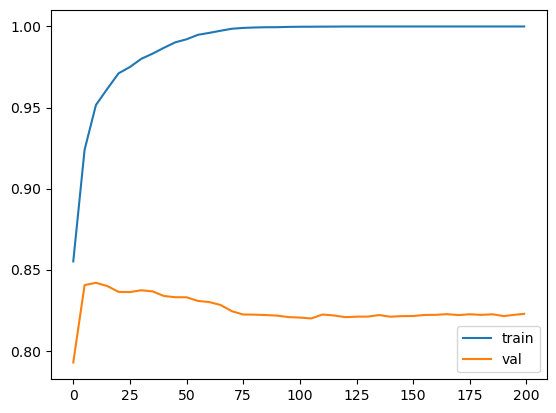

In [114]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

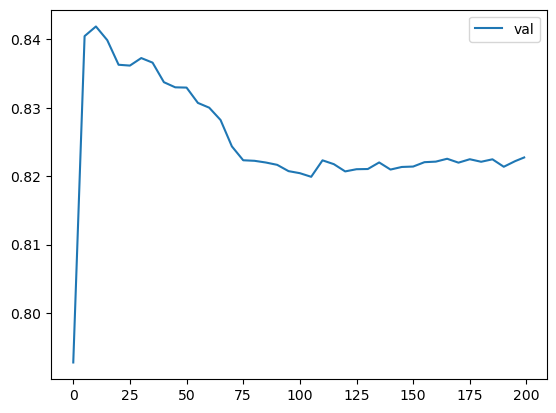

In [115]:
# 只看验证集
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

# 6.8 XGBoost parameter tuning              XGBoost 参数调优
Tuning the following parameters:            调整以下参数：

· eta                                        

· max_depth

· min_child_weight

### 上一课中，我们使用了梯度提升模型进行了训练，使用的基本都是模型的默认参数
-1. 我们发现在25个决策树左右，验证数据的auc可以达到一个峰值，82%左右，之后性能开始下降。
### 这节，我们将调整三个参数：eta  ， max_depth  , min_child_weight 

In [116]:
scores = {}

In [128]:
%%capture output

xgb_params = {
    'eta': 1.0, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watch_list)


In [129]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=1.0'

### 先执行1次119 cell中的代码，让已经 完成了eta等于0.3的数据写入到scores字典中，
### 然后，将上面的117 cell中的eta参数，分别输入1.0，0.1，0.05，0.01 ，然后依次执行121，将不同eta值得结果，写入到scores字典中

In [130]:
scores.keys()

dict_keys(['eta=0.01', 'eta=0.3', 'eta=0.05', 'eta=0.1', 'eta=1.0'])

In [131]:
scores

{'eta=0.01':     num_iter  train_auc  val_auc
 0          0    0.85509  0.79275
 1          5    0.85710  0.80226
 2         10    0.86374  0.80801
 3         15    0.86731  0.80967
 4         20    0.87090  0.81500
 5         25    0.87704  0.82226
 6         30    0.87963  0.82497
 7         35    0.88411  0.83273
 8         40    0.88917  0.83886
 9         45    0.89275  0.84269
 10        50    0.89518  0.84453
 11        55    0.89701  0.84583
 12        60    0.89894  0.84722
 13        65    0.90065  0.84777
 14        70    0.90300  0.84871
 15        75    0.90497  0.84996
 16        80    0.90748  0.85070
 17        85    0.90964  0.85151
 18        90    0.91158  0.85194
 19        95    0.91302  0.85231
 20       100    0.91420  0.85383
 21       105    0.91563  0.85484
 22       110    0.91703  0.85572
 23       115    0.91799  0.85633
 24       120    0.91963  0.85702
 25       125    0.92105  0.85762
 26       130    0.92271  0.85841
 27       135    0.92431  0.85884
 2

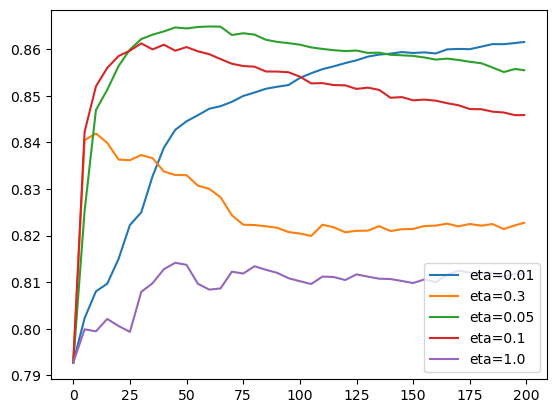

In [132]:
for key,df_scores in scores.items():
    plt.plot(df_scores.num_iter ,df_scores.val_auc,label=key )
plt.legend()

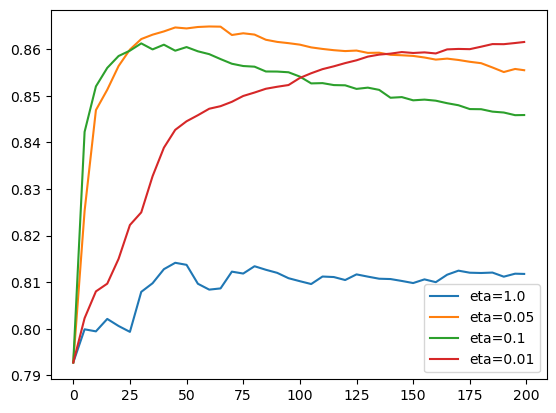

In [170]:
# 跟容易理解得一种图
etas = ['eta=1.0','eta=0.05','eta=0.1','eta=0.01']

for eta in etas:
    df_scores = scores[eta]
    plt.plot(df_scores.num_iter ,df_scores.val_auc,label=eta )
plt.legend()

### 图表核心信息解读
- 横轴 (num_iter)：训练的轮数，也就是生成了多少棵树。

- 纵轴 (val_auc)：模型在验证集上的 AUC 分数。AUC 越高，模型性能越好。

- 三条线：分别代表 eta 为 1.0、0.3 和 0.1 时，模型性能随训练轮数的变化轨迹。

###   蓝色线 (eta=1.0)：缓慢上升，但是抵达峰值后效果不佳，且不再改善，保持较低预期得平稳状态
###   绿色线（eta=0.1）：激进冲刺，快速过拟合，它在第30 轮就冲到了最高的 AUC（约 0.86），但之后曲线加速下跌
###   橙色线（eta=0.05）：学习率小，50轮左右见顶，峰值较其他两个都高，且抵达峰值后，较为平缓得下跌 
###   红色线（eta=0.01）：学习率最小，200左右见顶，峰值是最高得

### 所以，回到前1个有5个eta值得图表，我们认为，0.05是最合适eta值，
## #我们罗列一下alexey调参顺序
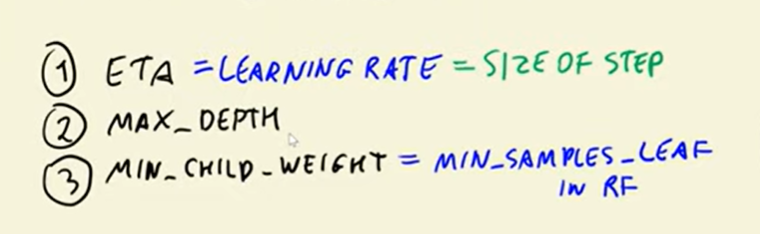

## # 开始1个新得训练，保留前面找到得eta最佳值=0.05

In [171]:
# 先调整maxdepth得值
scores2 = {}

In [181]:
%%capture output

xgb_params = {
    'eta': 0.01, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watch_list)


In [182]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores2[key] = parse_xgb_output(output)
key

'max_depth=6'

In [183]:
scores2.keys()  # 这里scores2字典得key值完善，与前面得eta得多个值得填充方式一样，手动输入要测试得值，手动执行代码

dict_keys(['max_depth=3', 'max_depth=4', 'max_depth=5', 'max_depth=6'])

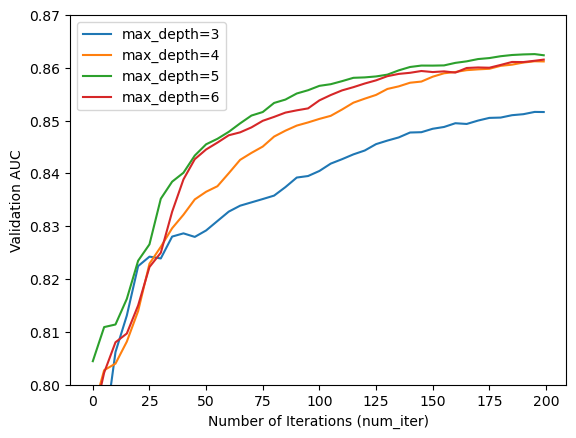

In [184]:
for key,df_scores2 in scores2.items():
    plt.plot(df_scores2.num_iter ,df_scores2.val_auc,label=key )
plt.ylim(0.8,0.87)
plt.xlabel('Number of Iterations (num_iter)')
plt.ylabel('Validation AUC')
plt.legend()

### 蓝色得线，是最差得，且与其他线，差距巨大，我们可以忽略他。
###  从上图可以看出 ：***'max_depth': 5*** ，无疑是最优解

## # 开始1个新得训练，保留前面找到得eta最佳值=0.01，'max_depth': 5 

In [185]:
# 调整min_child_weight 得值,采用1，10，30，三个数值
scores3 = {}

In [192]:
%%capture output

xgb_params = {
    'eta': 0.01, 
    'max_depth': 5,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watch_list)


In [193]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores3[key] = parse_xgb_output(output)
key

'min_child_weight=1'

In [194]:
scores3.keys()

dict_keys(['min_child_weight=30', 'min_child_weight=10', 'min_child_weight=1'])

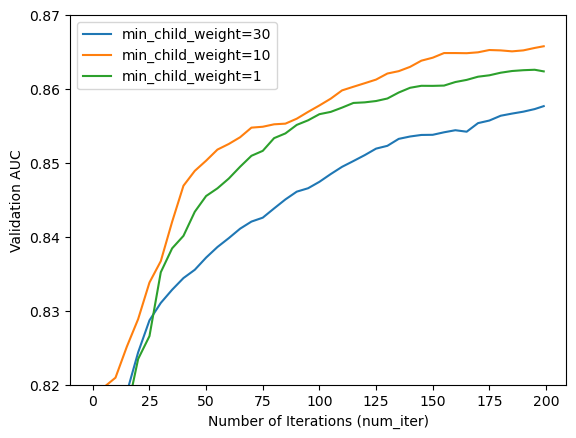

In [196]:
for key,df_scores3 in scores3.items():
    plt.plot(df_scores3.num_iter ,df_scores3.val_auc,label=key )
plt.ylim(0.82,0.87)
plt.xlabel('Number of Iterations (num_iter)')
plt.ylabel('Validation AUC')
plt.legend()

### 根据上图， 'min_child_weight': 10, 这个值是最佳的，那么我们也对应的选择 200 作为num_boost_round 的数量
### 我们开始训练最终模型

In [ ]:

xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 30,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dtrain, num_boost_round=175,
                  verbose_eval=5,
                  evals=watch_list)


# 6.9 Selecting the final model             选择最终模型
· Choosing between xgboost, random forest and decision tree      在 xgboost、随机森林和决策树之间进行选择    

· Training the final model                                       训练最终模型  

· Saving the model                                               保存模型

## 训练最终模型，并选择最终模型


In [197]:
# 最优的决策树模型
dt_model2 =  DecisionTreeClassifier(max_depth=6, min_samples_leaf=100) 
dt_model2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [198]:
y_pred = dt_model2.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.823057902973396

In [199]:
# 最优的随机森林模型
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=5,
                            random_state=1)
rf.fit(X_train, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [200]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8607699530516432

In [202]:
# 最优的xGboost模型
xgb_params = {
    'eta': 0.01, 
    'max_depth': 5,
    'min_child_weight': 10,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watch_list)

[0]	train-auc:0.81219	val-auc:0.81766
[5]	train-auc:0.81430	val-auc:0.81967
[10]	train-auc:0.81638	val-auc:0.82093
[15]	train-auc:0.82025	val-auc:0.82512
[20]	train-auc:0.82346	val-auc:0.82886
[25]	train-auc:0.82742	val-auc:0.83381
[30]	train-auc:0.82875	val-auc:0.83670
[35]	train-auc:0.83505	val-auc:0.84202
[40]	train-auc:0.83830	val-auc:0.84690
[45]	train-auc:0.84174	val-auc:0.84891
[50]	train-auc:0.84372	val-auc:0.85029
[55]	train-auc:0.84613	val-auc:0.85179
[60]	train-auc:0.84814	val-auc:0.85255
[65]	train-auc:0.85050	val-auc:0.85346
[70]	train-auc:0.85219	val-auc:0.85476
[75]	train-auc:0.85406	val-auc:0.85488
[80]	train-auc:0.85565	val-auc:0.85521
[85]	train-auc:0.85673	val-auc:0.85530
[90]	train-auc:0.85790	val-auc:0.85597
[95]	train-auc:0.85948	val-auc:0.85689
[100]	train-auc:0.86101	val-auc:0.85776
[105]	train-auc:0.86267	val-auc:0.85868
[110]	train-auc:0.86373	val-auc:0.85980
[115]	train-auc:0.86453	val-auc:0.86029
[120]	train-auc:0.86620	val-auc:0.86077
[125]	train-auc:0.8678

In [203]:
y_pred = tuning_model.predict(dval)
roc_auc_score(y_val, y_pred)

0.8657652582159625

## 用测试集去测试

In [32]:
df_full_train = df_full_train.reset_index(drop = True)

In [33]:
y_full_train = (df_full_train.status =='default').astype(int).values

In [34]:
del df_full_train['status']

In [39]:
dicts_full_train = df_full_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False) 
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.fillna(0).to_dict(orient='records')
X_test = dv.transform(dicts_test) 



In [40]:
dfulltrain = xgb.DMatrix(
    X_full_train,
    label=y_full_train,
    feature_names=dv.get_feature_names_out().tolist())
dtest = xgb.DMatrix(X_test,label=y_test, feature_names=dv.get_feature_names_out().tolist())

In [41]:
xgb_params = {
    'eta': 0.01, 
    'max_depth': 5,
    'min_child_weight': 10,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

tuning_model = xgb.train(xgb_params, dfulltrain, num_boost_round=175,
                  verbose_eval=5)

In [42]:
y_pred = tuning_model.predict(dtest)

In [43]:
roc_auc_score(y_test, y_pred)

0.8425620463888748